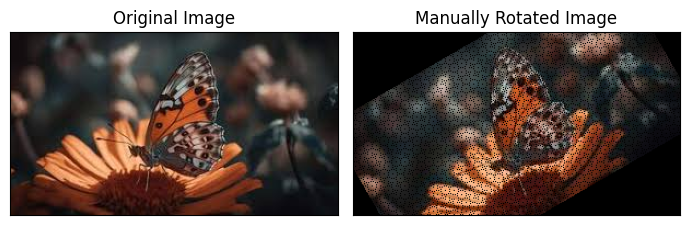

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
img = cv2.imread(r"C:\Users\JAI\Downloads\images.jpg")
image_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


angle = 30 
height, width = image_rgb.shape[:2]  


center = (width // 2, height // 2)


theta = np.radians(angle)
cos_angle = np.cos(theta)
sin_angle = np.sin(theta)


rotation_matrix = np.array([
    [cos_angle, -sin_angle, center[0] - center[0] * cos_angle + center[1] * sin_angle],
    [sin_angle, cos_angle, center[1] - center[0] * sin_angle - center[1] * cos_angle]
])


rotated_image = np.zeros_like(image_rgb)

for y in range(height):
    for x in range(width):
        new_x = int((cos_angle * (x - center[0]) + sin_angle * (y - center[1]) + center[0]))
        new_y = int((-sin_angle * (x - center[0]) + cos_angle * (y - center[1]) + center[1]))

        # Check if the new position is within the image bounds
        if 0 <= new_x < width and 0 <= new_y < height:
            rotated_image[new_y, new_x] = image_rgb[y, x]


fig, axs = plt.subplots(1, 2, figsize=(7, 4))
axs[0].imshow(image_rgb)
axs[0].set_title('Original Image')
axs[1].imshow(rotated_image)
axs[1].set_title('Manually Rotated Image')

for ax in axs:
    ax.set_xticks([]) 
    ax.set_yticks([])

plt.tight_layout()
plt.show()


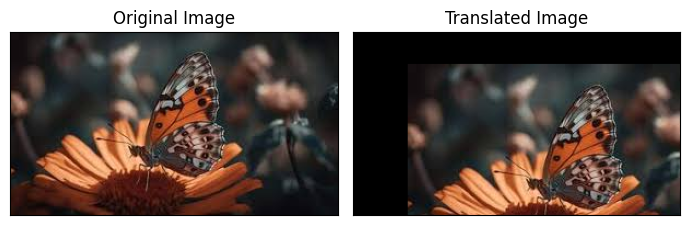

In [12]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Step 1: Load the image and convert to RGB (as OpenCV loads in BGR by default)
img = cv2.imread(r"C:\Users\JAI\Downloads\images.jpg")
image_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Step 2: Define translation parameters (how much to shift the image)
dx = 50 
dy = 30  

height, width = image_rgb.shape[:2]  # Get image dimensions

# Step 3: Create the translation matrix
# Translation matrix to move by (dx, dy)
translation_matrix = np.array([
    [1, 0, dx],  # Move x by dx
    [0, 1, dy],  # Move y by dy
])

# Step 4: Create an empty image for the translated image
translated_image = np.zeros_like(image_rgb)

# Step 5: Perform the translation
for y in range(height):
    for x in range(width):
        # Apply the translation matrix to the pixel's coordinates
        new_x = x + dx
        new_y = y + dy

        # Check if the new position is within bounds of the image
        if 0 <= new_x < width and 0 <= new_y < height:
            translated_image[new_y, new_x] = image_rgb[y, x]

# Step 6: Create subplots to show the original and translated images
fig, axs = plt.subplots(1, 2, figsize=(7, 4))

# Plot the original image
axs[0].imshow(image_rgb)
axs[0].set_title('Original Image')

# Plot the translated image
axs[1].imshow(translated_image)
axs[1].set_title('Translated Image')

# Remove ticks from the subplots
for ax in axs:
    ax.set_xticks([]) 
    ax.set_yticks([])

# Display the subplots
plt.tight_layout()
plt.show()


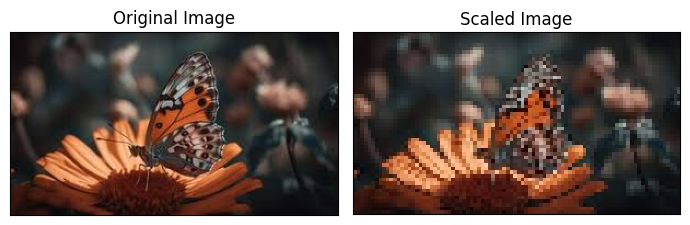

In [22]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Step 1: Load the image and convert to RGB (as OpenCV loads in BGR by default)
img = cv2.imread(r"C:\Users\JAI\Downloads\images.jpg")
image_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Step 2: Define scaling factors (how much to scale the image)
scale_x = 0.3 # Scale factor for width (1.5 times the original width)
scale_y = 0.3 # Scale factor for height (1.5 times the original height)

height, width = image_rgb.shape[:2]  # Get original image dimensions

# Step 3: Calculate the new dimensions of the image
new_width = int(width * scale_x)
new_height = int(height * scale_y)

# Step 4: Create an empty image for the scaled image
scaled_image = np.zeros((new_height, new_width, 3), dtype=np.uint8)

# Step 5: Perform the scaling (map each pixel from the original image to the scaled image)
for y in range(new_height):
    for x in range(new_width):
        # Calculate the corresponding coordinates in the original image
        original_x = int(x / scale_x)
        original_y = int(y / scale_y)

        # Check if the corresponding coordinates are within the bounds of the original image
        if 0 <= original_x < width and 0 <= original_y < height:
            scaled_image[y, x] = image_rgb[original_y, original_x]

# Step 6: Create subplots to show the original and scaled images
fig, axs = plt.subplots(1, 2, figsize=(7, 4))

# Plot the original image
axs[0].imshow(image_rgb)
axs[0].set_title('Original Image')

# Plot the scaled image
axs[1].imshow(scaled_image)
axs[1].set_title('Scaled Image')

# Remove ticks from the subplots
for ax in axs:
    ax.set_xticks([]) 
    ax.set_yticks([])

# Display the subplots
plt.tight_layout()
plt.show()


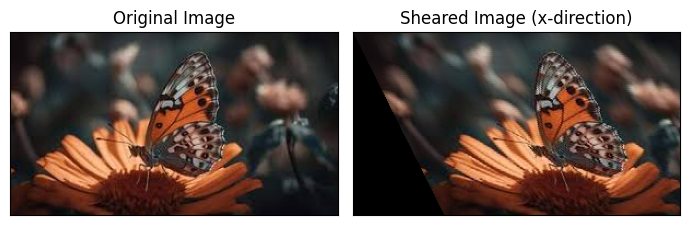

In [23]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Step 1: Load the image and convert to RGB (as OpenCV loads in BGR by default)
img = cv2.imread(r"C:\Users\JAI\Downloads\images.jpg")
image_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Step 2: Define shearing factor for x-direction
shear_x = 0.5  # Shear factor for x-direction

height, width = image_rgb.shape[:2]  # Get original image dimensions

# Step 3: Create the shear matrix for x-direction
shear_matrix = np.array([
    [1, shear_x, 0],  # x' = x + shear_x * y
    [0, 1, 0]         # y' = y (no change to y)
])

# Step 4: Create an empty image for the sheared image
sheared_image = np.zeros_like(image_rgb)

# Step 5: Perform the shearing (map each pixel from the original image to the sheared image)
for y in range(height):
    for x in range(width):
        # Apply the shear matrix to the pixel's coordinates
        new_x = int(x + shear_x * y)  # Sheared x-coordinate
        new_y = y  # y-coordinate remains unchanged

        # Check if the new position is within bounds of the image
        if 0 <= new_x < width and 0 <= new_y < height:
            sheared_image[new_y, new_x] = image_rgb[y, x]

# Step 6: Create subplots to show the original and sheared images
fig, axs = plt.subplots(1, 2, figsize=(7, 4))

# Plot the original image
axs[0].imshow(image_rgb)
axs[0].set_title('Original Image')

# Plot the sheared image
axs[1].imshow(sheared_image)
axs[1].set_title('Sheared Image (x-direction)')

# Remove ticks from the subplots
for ax in axs:
    ax.set_xticks([]) 
    ax.set_yticks([])

# Display the subplots
plt.tight_layout()
plt.show()


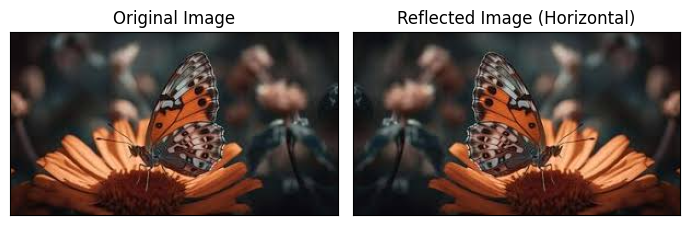

In [24]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Step 1: Load the image and convert to RGB (as OpenCV loads in BGR by default)
img = cv2.imread(r"C:\Users\JAI\Downloads\images.jpg")
image_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Step 2: Get the dimensions of the image
height, width = image_rgb.shape[:2]

# Step 3: Create the reflection matrix for horizontal reflection
reflection_matrix = np.array([
    [-1, 0, width],  # Flip horizontally along the x-axis
    [0, 1, 0]        # No change to y-axis
])

# Step 4: Create an empty image for the reflected image
reflected_image = np.zeros_like(image_rgb)

# Step 5: Perform the reflection (map each pixel from the original image to the reflected image)
for y in range(height):
    for x in range(width):
        # Calculate the new position for horizontal reflection
        new_x = width - x - 1  # Flip horizontally (mirror effect)
        new_y = y  # y-coordinate remains unchanged

        # Place the pixel in the new position
        reflected_image[new_y, new_x] = image_rgb[y, x]

# Step 6: Create subplots to show the original and reflected images
fig, axs = plt.subplots(1, 2, figsize=(7, 4))

# Plot the original image
axs[0].imshow(image_rgb)
axs[0].set_title('Original Image')

# Plot the reflected image
axs[1].imshow(reflected_image)
axs[1].set_title('Reflected Image (Horizontal)')

# Remove ticks from the subplots
for ax in axs:
    ax.set_xticks([]) 
    ax.set_yticks([])

# Display the subplots
plt.tight_layout()
plt.show()


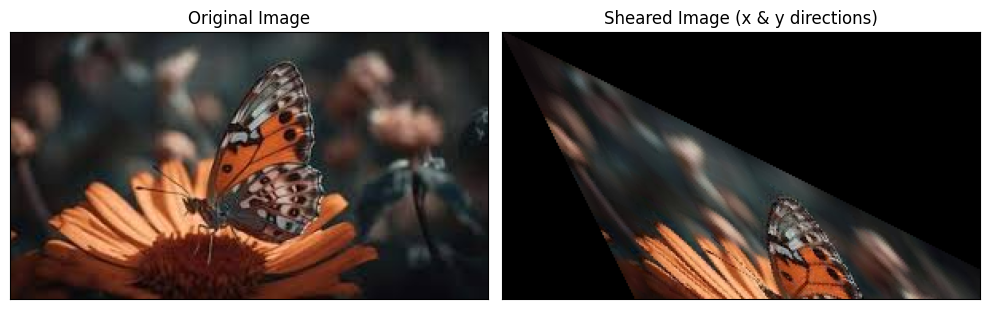

In [3]:
import numpy as np
import cv2
import matplotlib.pyplot as plt


img = cv2.imread(r"C:\Users\JAI\Downloads\images.jpg")
image_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


shear_x = 0.5  
shear_y = 0.5  

height, width = image_rgb.shape[:2] 


sheared_image = np.zeros_like(image_rgb)


for y in range(height):
    for x in range(width):
      
        new_x = int(x + shear_x * y)
        new_y = int(y + shear_y * x) 
        
      
        if 0 <= new_x < width and 0 <= new_y < height:
            sheared_image[new_y, new_x] = image_rgb[y, x]


fig, axs = plt.subplots(1, 2, figsize=(10, 5))


axs[0].imshow(image_rgb)
axs[0].set_title('Original Image')


axs[1].imshow(sheared_image)
axs[1].set_title('Sheared Image (x & y directions)')


for ax in axs:
    ax.set_xticks([])
    ax.set_yticks([])

# Display the images
plt.tight_layout()
plt.show()

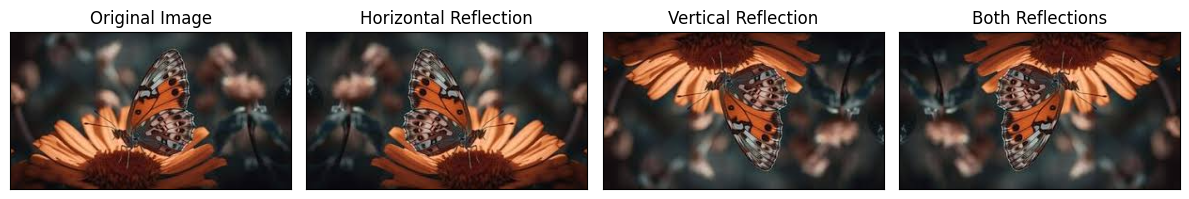

In [4]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Step 1: Load the image and convert to RGB
img = cv2.imread(r"C:\Users\JAI\Downloads\images.jpg")
image_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Step 2: Get the dimensions of the image
height, width = image_rgb.shape[:2]

# Step 3: Create empty images for the reflections
horizontal_reflection = np.zeros_like(image_rgb)
vertical_reflection = np.zeros_like(image_rgb)
both_reflection = np.zeros_like(image_rgb)

# Step 4: Perform the reflections
for y in range(height):
    for x in range(width):
        horizontal_reflection[y, width - x - 1] = image_rgb[y, x]  # Horizontal flip
        vertical_reflection[height - y - 1, x] = image_rgb[y, x]  # Vertical flip
        both_reflection[height - y - 1, width - x - 1] = image_rgb[y, x]  # Both flips

# Step 5: Create subplots to display the images
fig, axs = plt.subplots(1, 4, figsize=(12, 4))

axs[0].imshow(image_rgb)
axs[0].set_title('Original Image')

axs[1].imshow(horizontal_reflection)
axs[1].set_title('Horizontal Reflection')

axs[2].imshow(vertical_reflection)
axs[2].set_title('Vertical Reflection')

axs[3].imshow(both_reflection)
axs[3].set_title('Both Reflections')

# Remove ticks from the subplots
for ax in axs:
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()
